# Threat Intelligence ML Research Notebook

This notebook performs a single, end-to-end machine-learning research analysis across OTX threat pulses, CISA KEV-style CVE data, malicious domains, and malicious IP intelligence.

**Design goals**

- Load the four CSVs directly from `W:\archive`.
- Use `pandas` parsing rather than raw line counts, because WHOIS fields contain embedded newlines.
- Normalize `Unknown`, `{}`, blanks, and similar placeholders before analysis.
- Engineer features for text, categorical, temporal, and reputation/vote signals.
- Run reproducible ML workflows for topic discovery, classification, anomaly detection, and risk prioritization.
- Avoid artificial joins across datasets where no shared identifier exists.

**Important research caveat**

These datasets appear to mix confirmed threat intelligence, enrichment metadata, and scanner/vote output. The models below should be treated as analytical triage aids, not as production detection logic or ground truth.

## 1. Environment Setup

Run this cell first. It checks the requested ML/visualization stack and installs anything missing into the active Python environment.

In [1]:
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "plotly": "plotly",
}

missing = [
    package_name
    for import_name, package_name in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(import_name) is None
]

if missing:
    print("Installing missing packages:", ", ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
    print("Install complete. If imports still fail, restart the kernel and rerun from this cell.")
else:
    print("All required packages are available.")

All required packages are available.


In [2]:
from __future__ import annotations

import json
import math
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from IPython.display import Markdown, display

from sklearn.compose import ColumnTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    silhouette_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 160)
pd.set_option("display.width", 160)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titleweight"] = "bold"

try:
    import plotly.io as pio
    pio.renderers.default = "notebook_connected"
except Exception:
    pass

## 2. Configuration And Source Paths

All source files are configured in one place so this notebook can be rerun after the CSVs are refreshed.

In [3]:
DATA_PATHS = {
    "otx": Path(r"W:\archive\1_otx_threat_intel.csv"),
    "cve": Path(r"W:\archive\2_cve_vulnerabilities.csv"),
    "domains": Path(r"W:\archive\3_malicious_domains.csv"),
    "ips": Path(r"W:\archive\4_malicious_ips.csv"),
}

EXPECTED_ROWS = {
    "otx": 2365,
    "cve": 1585,
    "domains": 162,
    "ips": 200,
}

REQUIRED_COLUMNS = {
    "otx": [
        "Pulse_ID", "Title", "Description", "Author", "Created", "Modified", "TLP",
        "Tags", "Malware_Families", "Attack_IDs", "Industries", "Countries",
        "Indicators_Count", "Subscribers"
    ],
    "cve": [
        "cveID", "vendorProject", "product", "vulnerabilityName", "dateAdded",
        "shortDescription", "requiredAction", "dueDate",
        "knownRansomwareCampaignUse", "cwes"
    ],
    "domains": [
        "Domain", "TLD", "Domain_Length", "Has_Numbers", "Has_Hyphen",
        "Registrar", "Creation_Date", "Last_Update_Date", "Reputation",
        "Malicious_Votes", "Suspicious_Votes", "Harmless_Votes",
        "Undetected_Votes", "Total_Engines", "Threat_Severity", "Categories",
        "Popularity_Rank", "Last_Analysis_Date", "WHOIS_Summary", "Data_Source"
    ],
    "ips": [
        "IP", "Country", "Continent", "ASN", "Owner", "Network",
        "Malicious_Votes", "Suspicious_Votes", "Harmless_Votes",
        "Undetected_Votes", "Total_Reports", "Reputation_Score",
        "Threat_Label", "Threat_Category", "Regional_Registry",
        "WHOIS_Summary", "TOR_Node", "Times_Submitted",
        "Last_Analysis_Date", "Threat_Severity"
    ],
}

for name, path in DATA_PATHS.items():
    if not path.exists():
        raise FileNotFoundError(f"{name} source file not found: {path}")

print("Configured source files:")
for name, path in DATA_PATHS.items():
    print(f" - {name:8s} {path}")

Configured source files:
 - otx      W:\archive\1_otx_threat_intel.csv
 - cve      W:\archive\2_cve_vulnerabilities.csv
 - domains  W:\archive\3_malicious_domains.csv
 - ips      W:\archive\4_malicious_ips.csv


## 3. Utility Functions

These helpers keep cleaning, validation, feature engineering, and visualizations consistent across the four datasets.

In [4]:
PLACEHOLDER_VALUES = {"", "unknown", "none", "nan", "null", "n/a", "na", "{}"}


def normalize_scalar(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, str):
        cleaned = value.strip()
        if cleaned.lower() in PLACEHOLDER_VALUES:
            return np.nan
        return cleaned
    return value


def normalize_frame(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for col in out.select_dtypes(include=["object"]).columns:
        out[col] = out[col].map(normalize_scalar)
    return out


def split_multi(value) -> list[str]:
    value = normalize_scalar(value)
    if pd.isna(value):
        return []
    return [
        part.strip()
        for part in str(value).split(",")
        if part.strip() and part.strip().lower() not in PLACEHOLDER_VALUES
    ]


def explode_counts(df: pd.DataFrame, column: str, top_n: int = 20, lower: bool = False) -> pd.Series:
    values = df[column].apply(split_multi).explode()
    values = values.dropna()
    if lower:
        values = values.str.lower()
    return values.value_counts().head(top_n)


def to_number(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce")


def parse_datetime(series: pd.Series) -> pd.Series:
    return pd.to_datetime(series, errors="coerce")


def parse_unix_datetime(series: pd.Series) -> pd.Series:
    numeric = pd.to_numeric(series, errors="coerce")
    return pd.to_datetime(numeric, unit="s", errors="coerce")


def bool_from_yes_no(series: pd.Series) -> pd.Series:
    return (
        series.astype(str)
        .str.strip()
        .str.lower()
        .map({"yes": 1, "true": 1, "1": 1, "no": 0, "false": 0, "0": 0})
        .astype("float")
    )


def validate_columns(df: pd.DataFrame, name: str) -> None:
    missing = sorted(set(REQUIRED_COLUMNS[name]) - set(df.columns))
    if missing:
        raise ValueError(f"{name} is missing required columns: {missing}")


def missing_profile(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for col in df.columns:
        raw = df[col]
        placeholder = raw.astype(str).str.strip().str.lower().isin(PLACEHOLDER_VALUES).sum()
        missing = raw.isna().sum()
        total = int(missing + placeholder)
        rows.append(
            {
                "column": col,
                "missing_or_placeholder": total,
                "pct": total / len(df) if len(df) else np.nan,
                "dtype": str(raw.dtype),
                "unique_non_null": raw.dropna().nunique(),
            }
        )
    return pd.DataFrame(rows).sort_values(["missing_or_placeholder", "column"], ascending=[False, True])


def show_top(series: pd.Series, title: str, x_label: str = "Count", top_n: int = 15):
    data = series.head(top_n).sort_values(ascending=True)
    fig = px.bar(
        data,
        x=data.values,
        y=data.index,
        orientation="h",
        labels={"x": x_label, "y": ""},
        title=title,
        template="plotly_white",
    )
    fig.update_layout(height=max(420, 28 * len(data)), title_x=0.02)
    fig.show()
    return data.sort_values(ascending=False)


def severity_ordered_counts(df: pd.DataFrame, column: str = "Threat_Severity") -> pd.Series:
    order = ["Low", "Medium", "High", "Critical"]
    counts = df[column].fillna("Missing").value_counts()
    ordered = [item for item in order if item in counts.index] + [
        item for item in counts.index if item not in order
    ]
    return counts.loc[ordered]


def safe_train_test_split(X, y, test_size=0.25):
    counts = pd.Series(y).value_counts()
    stratify = y if len(counts) > 1 and counts.min() >= 2 else None
    return train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=RANDOM_STATE,
        stratify=stratify,
    )


def model_report(name: str, y_true, y_pred, labels=None) -> dict:
    report = {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
    }
    display(Markdown(f"### {name}"))
    display(pd.DataFrame([report]))
    print(classification_report(y_true, y_pred, zero_division=0))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels if labels is not None else "auto",
        yticklabels=labels if labels is not None else "auto",
    )
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()
    return report


def numeric_anomaly_detection(df: pd.DataFrame, feature_cols: list[str], id_col: str, contamination: float = 0.08) -> pd.DataFrame:
    model_df = df[[id_col] + feature_cols].copy()
    for col in feature_cols:
        model_df[col] = pd.to_numeric(model_df[col], errors="coerce")
    pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", IsolationForest(contamination=contamination, random_state=RANDOM_STATE)),
        ]
    )
    predictions = pipe.fit_predict(model_df[feature_cols])
    scores = pipe.named_steps["model"].decision_function(
        pipe.named_steps["scaler"].transform(
            pipe.named_steps["imputer"].transform(model_df[feature_cols])
        )
    )
    result = model_df.copy()
    result["anomaly_flag"] = predictions
    result["anomaly_score"] = scores
    return result.sort_values("anomaly_score")

## 4. Load Data

The parser uses `pandas.read_csv`, which correctly handles quoted embedded newlines in WHOIS fields.

In [5]:
raw = {name: pd.read_csv(path) for name, path in DATA_PATHS.items()}

for name, df in raw.items():
    validate_columns(df, name)

row_summary = pd.DataFrame(
    [
        {
            "dataset": name,
            "parsed_rows": len(df),
            "expected_rows": EXPECTED_ROWS[name],
            "columns": df.shape[1],
            "matches_expected": len(df) == EXPECTED_ROWS[name],
        }
        for name, df in raw.items()
    ]
)
display(row_summary)

if not row_summary["matches_expected"].all():
    display(Markdown("**Note:** one or more row counts differ from the original baseline. Continue, but inspect source refreshes."))

samples = {name: df.head(3) for name, df in raw.items()}
for name, sample in samples.items():
    display(Markdown(f"### Sample: {name}"))
    display(sample)

,dataset,parsed_rows,expected_rows,columns,matches_expected
0,otx,2365,2365,14,True
1,cve,1585,1585,10,True
2,domains,162,162,20,True
3,ips,200,200,20,True


### Sample: otx

,Pulse_ID,Title,Description,Author,Created,Modified,TLP,Tags,Malware_Families,Attack_IDs,Industries,Countries,Indicators_Count,Subscribers
0,69f1e236e4e192f639298d53,Multi-Stage Malware Execution Chain Analysis,A sophisticated multi-stage malware execution chain was discovered during proactive threat hunting activities using endpoint telemetry and dynamic analysis....,AlienVault,2026-04-29T10:49:26.327000,2026-04-29T10:50:57.999000,white,"payload extraction, c2 communication, defense evasion, multi-stage attack, data exfiltration, lateral movement, script masquerading",Unknown,"T1036.005, T1082, T1071, T1140, T1036, T1055, T1090, T1059, T1083, T1497, T1102, T1041, T1059.001, T1027, T1573, T1132, T1059.003, T1071.001, T1105",Unknown,Unknown,0.0,0.0
1,69f1de85544538ce8b03332a,User interaction with a ClickFix-style phishing site resulted in execution of an obfuscated PowerShell command,A ClickFix-style phishing campaign leveraged social engineering to trick users into executing obfuscated PowerShell commands that downloaded and installed a...,AlienVault,2026-04-29T10:33:41.967000,2026-04-29T10:44:36.742000,white,"phishing, lumma stealer, powershell, information stealer, credential theft, hijackloader, dll sideloading, lummastealer, clickfix","HijackLoader, Lumma Stealer - S1213, LummaStealer","T1218.007, T1005, T1555, T1036, T1055, T1059, T1204, T1041, T1059.001, T1566, T1027, T1573, T1071.001, T1574.002, T1105",Unknown,Unknown,0.0,0.0
2,69f1d20216d6091f01f8a6eb,Kyber ransomware is not just post-quantum name-dropping,A detailed technical analysis confirms that Kyber ransomware implements genuine hybrid post-quantum cryptography rather than mere branding. The Rust-based W...,AlienVault,2026-04-29T09:40:17.996000,2026-04-29T10:14:38.724000,white,"post-quantum cryptography, x25519, aes-ctr encryption, rust ransomware, hybrid encryption, file encryption, kyber, kyber1024",Kyber,"T1489, T1135, T1082, T1112, T1070.001, T1222, T1083, T1497, T1059.001, T1547.001, T1027, T1486, T1614, T1059.003, T1490","Defense, Technology",United States of America,0.0,0.0


### Sample: cve

,cveID,vendorProject,product,vulnerabilityName,dateAdded,shortDescription,requiredAction,dueDate,knownRansomwareCampaignUse,cwes
0,CVE-2024-1708,ConnectWise,ScreenConnect,ConnectWise ScreenConnect Path Traversal Vulnerability,2026-04-28,ConnectWise ScreenConnect contains a path traversal vulnerability which could allow an attacker to execute remote code or directly impact confidential data ...,"Apply mitigations per vendor instructions, follow applicable BOD 22-01 guidance for cloud services, or discontinue use of the product if mitigations are una...",2026-05-12,Unknown,CWE-22
1,CVE-2026-32202,Microsoft,Windows,Microsoft Windows Protection Mechanism Failure Vulnerability,2026-04-28,Microsoft Windows Shell contains a protection mechanism failure vulnerability that allows an unauthorized attacker to perform spoofing over a network.,"Apply mitigations per vendor instructions, follow applicable BOD 22-01 guidance for cloud services, or discontinue use of the product if mitigations are una...",2026-05-12,Unknown,CWE-693
2,CVE-2025-29635,D-Link,DIR-823X,D-Link DIR-823X Command Injection Vulnerability,2026-04-24,D-Link DIR-823X contains a command injection vulnerability that allows an authorized attacker to execute arbitrary commands on remote devices by sending a P...,"Apply mitigations per vendor instructions, follow applicable BOD 22-01 guidance for cloud services, or discontinue use of the product if mitigations are una...",2026-05-08,Unknown,CWE-77


### Sample: domains

,Domain,TLD,Domain_Length,Has_Numbers,Has_Hyphen,Registrar,Creation_Date,Last_Update_Date,Reputation,Malicious_Votes,Suspicious_Votes,Harmless_Votes,Undetected_Votes,Total_Engines,Threat_Severity,Categories,Popularity_Rank,Last_Analysis_Date,WHOIS_Summary,Data_Source
0,urlhaus.abuse.ch,ch,16,No,No,Unknown,Unknown,Unknown,2,0,0,59,32,91,Low,{},Unknown,1777636885.0,DNSSEC:Y,VirusTotal
1,bazaar.abuse.ch,ch,15,No,No,Unknown,Unknown,Unknown,6,1,0,58,32,91,Low,{},Unknown,1777636949.0,DNSSEC:Y,VirusTotal
2,feodotracker.abuse.ch,ch,21,No,No,Unknown,Unknown,Unknown,1,0,0,59,32,91,Low,{},Unknown,1777627712.0,DNSSEC:Y,VirusTotal


### Sample: ips

,IP,Country,Continent,ASN,Owner,Network,Malicious_Votes,Suspicious_Votes,Harmless_Votes,Undetected_Votes,Total_Reports,Reputation_Score,Threat_Label,Threat_Category,Regional_Registry,WHOIS_Summary,TOR_Node,Times_Submitted,Last_Analysis_Date,Threat_Severity
0,176.10.99.200,CH,EU,51395.0,Datasource AG,176.10.96.0/19,3,0,55,33,91,-26,clean,clean,RIPE NCC,inetnum: 176.10.99.192 - 176.10.99.223\nnetname: Feral214Management\ncountry: CH\nadmin-c: RT4480-RIPE\n,No,0,1777589108,Low
1,176.10.99.201,CH,EU,51395.0,Datasource AG,176.10.96.0/19,0,1,53,37,91,0,unrated,clean,RIPE NCC,inetnum: 176.10.99.192 - 176.10.99.223\nnetname: Feral214Management\ncountry: CH\nadmin-c: RT4480-RIPE\n,No,0,1776571431,Low
2,77.247.181.162,NL,EU,43350.0,NForce Entertainment B.V.,77.247.176.0/21,4,1,53,33,91,-19,unrated,clean,RIPE NCC,inetnum: 77.247.181.160 - 77.247.181.175\nnetname: ZWIEBELFREUNDE\ndescr: Customer 692 / Zwiebelfreund,No,0,1777589035,Medium


## 5. Data Quality Profile

Before cleaning, profile row counts, duplicate keys, placeholder-heavy columns, and date parseability.

In [6]:
key_columns = {
    "otx": "Pulse_ID",
    "cve": "cveID",
    "domains": "Domain",
    "ips": "IP",
}

quality_rows = []
for name, df in raw.items():
    key = key_columns[name]
    quality_rows.append(
        {
            "dataset": name,
            "rows": len(df),
            "columns": df.shape[1],
            "duplicate_full_rows": int(df.duplicated().sum()),
            f"duplicate_{key}": int(df[key].duplicated().sum()),
            "memory_mb": round(df.memory_usage(deep=True).sum() / 1024**2, 3),
        }
    )

display(pd.DataFrame(quality_rows))

for name, df in raw.items():
    display(Markdown(f"### Missing / Placeholder Profile: {name}"))
    display(missing_profile(df).head(12))

,dataset,rows,columns,duplicate_full_rows,duplicate_Pulse_ID,memory_mb,duplicate_cveID,duplicate_Domain,duplicate_IP
0,otx,2365,14,0,25.0,3.004,NaN,NaN,NaN
1,cve,1585,10,0,NaN,1.376,0.0,NaN,NaN
2,domains,162,20,0,NaN,0.137,NaN,0.0,NaN
3,ips,200,20,0,NaN,0.157,NaN,NaN,0.0


### Missing / Placeholder Profile: otx

,column,missing_or_placeholder,pct,dtype,unique_non_null
11,Countries,1306,0.552220,object,530
10,Industries,1229,0.519662,object,470
8,Malware_Families,656,0.277378,object,1457
9,Attack_IDs,189,0.079915,object,2129
7,Tags,12,0.005074,object,2329
2,Description,2,0.000846,object,2361
3,Author,0,0.000000,object,1
4,Created,0,0.000000,object,2340
12,Indicators_Count,0,0.000000,float64,1
5,Modified,0,0.000000,object,2085


### Missing / Placeholder Profile: cve

,column,missing_or_placeholder,pct,dtype,unique_non_null
8,knownRansomwareCampaignUse,1268,0.800000,object,2
9,cwes,167,0.105363,object,228
0,cveID,0,0.000000,object,1585
4,dateAdded,0,0.000000,object,410
7,dueDate,0,0.000000,object,424
2,product,0,0.000000,object,642
6,requiredAction,0,0.000000,object,42
5,shortDescription,0,0.000000,object,1498
1,vendorProject,0,0.000000,object,258
3,vulnerabilityName,0,0.000000,object,1257


### Missing / Placeholder Profile: domains

,column,missing_or_placeholder,pct,dtype,unique_non_null
15,Categories,134,0.827160,object,29
16,Popularity_Rank,88,0.543210,object,75
5,Registrar,72,0.444444,object,53
7,Last_Update_Date,34,0.209877,object,127
6,Creation_Date,33,0.203704,object,129
18,WHOIS_Summary,20,0.123457,object,123
17,Last_Analysis_Date,4,0.024691,object,157
19,Data_Source,0,0.000000,object,1
0,Domain,0,0.000000,object,162
2,Domain_Length,0,0.000000,int64,23


### Missing / Placeholder Profile: ips

,column,missing_or_placeholder,pct,dtype,unique_non_null
2,Continent,48,0.240,object,4
15,WHOIS_Summary,24,0.120,object,83
3,ASN,17,0.085,object,31
5,Network,17,0.085,object,53
4,Owner,17,0.085,object,30
1,Country,16,0.080,object,24
14,Regional_Registry,16,0.080,object,5
8,Harmless_Votes,0,0.000,int64,20
0,IP,0,0.000,object,200
18,Last_Analysis_Date,0,0.000,int64,197


## 6. Clean And Type Data

Cleaning is intentionally transparent: it preserves original columns while adding parsed and engineered fields.

In [7]:
otx = normalize_frame(raw["otx"])
cve = normalize_frame(raw["cve"])
domains = normalize_frame(raw["domains"])
ips = normalize_frame(raw["ips"])

# OTX: keep the latest modified copy for repeated Pulse_ID values.
otx["Created_dt"] = parse_datetime(otx["Created"])
otx["Modified_dt"] = parse_datetime(otx["Modified"])
otx["Indicators_Count_num"] = to_number(otx["Indicators_Count"])
otx["Subscribers_num"] = to_number(otx["Subscribers"])
otx = (
    otx.sort_values(["Pulse_ID", "Modified_dt"], ascending=[True, False])
    .drop_duplicates("Pulse_ID", keep="first")
    .reset_index(drop=True)
)
otx["created_month"] = otx["Created_dt"].dt.to_period("M").astype(str)
otx["created_year"] = otx["Created_dt"].dt.year
otx["text"] = (
    otx[["Title", "Description", "Tags", "Malware_Families", "Attack_IDs"]]
    .fillna("")
    .agg(" ".join, axis=1)
)

# CVE.
cve["dateAdded_dt"] = parse_datetime(cve["dateAdded"])
cve["dueDate_dt"] = parse_datetime(cve["dueDate"])
cve["days_to_due"] = (cve["dueDate_dt"] - cve["dateAdded_dt"]).dt.days
cve["ransomware_known"] = cve["knownRansomwareCampaignUse"].eq("Known").astype(int)
cve["text"] = (
    cve[["vendorProject", "product", "vulnerabilityName", "shortDescription", "requiredAction", "cwes"]]
    .fillna("")
    .agg(" ".join, axis=1)
)
cve["cwes_clean"] = cve["cwes"].fillna("")

# Domains.
numeric_domain_cols = [
    "Domain_Length", "Creation_Date", "Last_Update_Date", "Reputation",
    "Malicious_Votes", "Suspicious_Votes", "Harmless_Votes",
    "Undetected_Votes", "Total_Engines", "Popularity_Rank", "Last_Analysis_Date"
]
for col in numeric_domain_cols:
    domains[col + "_num"] = to_number(domains[col])
domains["Has_Numbers_bin"] = bool_from_yes_no(domains["Has_Numbers"])
domains["Has_Hyphen_bin"] = bool_from_yes_no(domains["Has_Hyphen"])
domains["Creation_Date_dt"] = parse_unix_datetime(domains["Creation_Date_num"])
domains["Last_Update_Date_dt"] = parse_unix_datetime(domains["Last_Update_Date_num"])
domains["Last_Analysis_Date_dt"] = parse_unix_datetime(domains["Last_Analysis_Date_num"])
domains["domain_age_days"] = (
    domains["Last_Analysis_Date_dt"] - domains["Creation_Date_dt"]
).dt.days
domains["malicious_rate"] = domains["Malicious_Votes_num"] / domains["Total_Engines_num"].replace(0, np.nan)
domains["suspicious_rate"] = domains["Suspicious_Votes_num"] / domains["Total_Engines_num"].replace(0, np.nan)
domains["signal_rate"] = (
    domains["Malicious_Votes_num"] + domains["Suspicious_Votes_num"]
) / domains["Total_Engines_num"].replace(0, np.nan)

# IPs.
numeric_ip_cols = [
    "ASN", "Malicious_Votes", "Suspicious_Votes", "Harmless_Votes",
    "Undetected_Votes", "Total_Reports", "Reputation_Score",
    "Times_Submitted", "Last_Analysis_Date"
]
for col in numeric_ip_cols:
    ips[col + "_num"] = to_number(ips[col])
ips["TOR_Node_bin"] = bool_from_yes_no(ips["TOR_Node"])
ips["Last_Analysis_Date_dt"] = parse_unix_datetime(ips["Last_Analysis_Date_num"])
ips["malicious_rate"] = ips["Malicious_Votes_num"] / ips["Total_Reports_num"].replace(0, np.nan)
ips["suspicious_rate"] = ips["Suspicious_Votes_num"] / ips["Total_Reports_num"].replace(0, np.nan)
ips["signal_rate"] = (
    ips["Malicious_Votes_num"] + ips["Suspicious_Votes_num"]
) / ips["Total_Reports_num"].replace(0, np.nan)

clean_summary = pd.DataFrame(
    [
        {"dataset": "otx", "rows_after_cleaning": len(otx), "dedupe_key": "Pulse_ID"},
        {"dataset": "cve", "rows_after_cleaning": len(cve), "dedupe_key": "cveID"},
        {"dataset": "domains", "rows_after_cleaning": len(domains), "dedupe_key": "Domain"},
        {"dataset": "ips", "rows_after_cleaning": len(ips), "dedupe_key": "IP"},
    ]
)
display(clean_summary)

,dataset,rows_after_cleaning,dedupe_key
0,otx,2340,Pulse_ID
1,cve,1585,cveID
2,domains,162,Domain
3,ips,200,IP


## 7. OTX Threat Pulse Analysis

This section profiles threat themes, MITRE ATT&CK techniques, malware families, affected sectors, and temporal behavior.

In [8]:
display(Markdown("### OTX Timeline"))
otx_timeline = otx.dropna(subset=["Created_dt"]).groupby(pd.Grouper(key="Created_dt", freq="M")).size().reset_index(name="pulses")
fig = px.line(
    otx_timeline,
    x="Created_dt",
    y="pulses",
    title="OTX Threat Pulses Over Time",
    markers=True,
    template="plotly_white",
)
fig.update_layout(title_x=0.02)
fig.show()

display(Markdown("### Top Tags"))
top_tags = explode_counts(otx, "Tags", top_n=20, lower=True)
display(top_tags.to_frame("count"))
show_top(top_tags, "Top OTX Tags", top_n=20)

display(Markdown("### Top MITRE ATT&CK Techniques"))
top_attack_ids = explode_counts(otx, "Attack_IDs", top_n=25)
display(top_attack_ids.to_frame("count"))
show_top(top_attack_ids, "Top MITRE ATT&CK Technique IDs", top_n=25)

display(Markdown("### Malware Families And Targeting"))
display(explode_counts(otx, "Malware_Families", top_n=20).to_frame("count"))
display(explode_counts(otx, "Industries", top_n=15).to_frame("count"))
display(explode_counts(otx, "Countries", top_n=15).to_frame("count"))

### OTX Timeline

### Top Tags

,count
Tags,
phishing,454
ransomware,240
social engineering,219
credential theft,191
powershell,168
persistence,165
apt,161
backdoor,156
cryptocurrency,152


### Top MITRE ATT&CK Techniques

,count
Attack_IDs,
T1027,996
T1082,749
T1140,630
T1105,620
T1566,618
T1083,590
T1059.001,568
T1078,560
T1055,541


### Malware Families And Targeting

,count
Malware_Families,
Cobalt Strike - S0154,62
Lumma Stealer,46
AsyncRAT,43
XMRig,35
XWorm,30
Rhadamanthys,29
Mirai,25
BeaverTail,23
Remcos,23


,count
Industries,
Government,547
Finance,395
Technology,343
Defense,186
Manufacturing,150
Telecommunications,143
Healthcare,131
Education,130
Energy,126


,count
Countries,
United States of America,329
Russian Federation,192
China,137
India,130
Ukraine,120
British Indian Ocean Territory,113
Brazil,100
Germany,98
United Kingdom of Great Britain and Northern Ireland,96


In [9]:
display(Markdown("### OTX Topic Discovery With TF-IDF, KMeans, And SVD"))

otx_topic_df = otx.dropna(subset=["text"]).copy()
vectorizer = TfidfVectorizer(
    max_features=3000,
    min_df=2,
    ngram_range=(1, 2),
    stop_words="english",
)
X_otx_text = vectorizer.fit_transform(otx_topic_df["text"])

n_clusters = min(7, max(3, len(otx_topic_df) // 250))
kmeans = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init=20)
otx_topic_df["cluster"] = kmeans.fit_predict(X_otx_text)

svd = TruncatedSVD(n_components=2, random_state=RANDOM_STATE)
coords = svd.fit_transform(X_otx_text)
otx_topic_df["svd_x"] = coords[:, 0]
otx_topic_df["svd_y"] = coords[:, 1]

if n_clusters > 1:
    silhouette = silhouette_score(coords, otx_topic_df["cluster"])
    display(Markdown(f"Approximate silhouette score on 2D SVD projection: **{silhouette:.3f}**"))

terms = np.array(vectorizer.get_feature_names_out())
topic_rows = []
for cluster_id in sorted(otx_topic_df["cluster"].unique()):
    center = kmeans.cluster_centers_[cluster_id]
    top_terms = terms[np.argsort(center)[-12:]][::-1]
    sample_titles = (
        otx_topic_df.loc[otx_topic_df["cluster"] == cluster_id, "Title"]
        .dropna()
        .head(5)
        .tolist()
    )
    topic_rows.append(
        {
            "cluster": cluster_id,
            "records": int((otx_topic_df["cluster"] == cluster_id).sum()),
            "top_terms": ", ".join(top_terms),
            "sample_titles": " | ".join(sample_titles),
        }
    )
otx_topics = pd.DataFrame(topic_rows)
display(otx_topics)

fig = px.scatter(
    otx_topic_df,
    x="svd_x",
    y="svd_y",
    color=otx_topic_df["cluster"].astype(str),
    hover_data=["Title", "Created_dt", "TLP"],
    title="OTX Text Topic Clusters",
    template="plotly_white",
)
fig.update_layout(title_x=0.02, legend_title_text="Cluster")
fig.show()

### OTX Topic Discovery With TF-IDF, KMeans, And SVD

C:\Users\thear\miniconda3\envs\ds\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\thear\miniconda3\envs\ds\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\thear\miniconda3\envs\ds\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\thear\miniconda3\envs\ds\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as pr

Approximate silhouette score on 2D SVD projection: **0.026**

,cluster,records,top_terms,sample_titles
0,0,695,"malware, 001, t1059, backdoor, malicious, threat, botnet, linux, 004, attack, supply, 002",New ELF malware on Shellshock: the ChinaZ | OPERATION QUANTUM ENTANGLEMENT | Magecarts fifth team began using KPOT for stealing activities | Analysis of an ...
1,1,97,"android, banking, trojan, banking trojan, malware, app, spyware, apps, mobile, sms, android malware, new android",BlankBot: A new Android banking trojan | Be careful what you wish for – Phishing in PWA applications | NGate Android malware relays NFC traffic to steal cas...
2,2,203,"stealer, lumma, 001, lumma stealer, malware, macos, infostealer, data, information, t1555, browser, fake","RHADAMANTHYS: In-Depth Analysis of a Sophisticated Stealer Targeting Israeli Users | InfoStealer Uses SwiftUI, OpenDirectory API to Capture Passwords | Mult..."
3,3,330,"phishing, t1566, 001, t1583, social, campaign, t1608, 002, t1589, t1585, fake, t1584",Advance Fee Fraud: The Emergence of Elaborate Crypto Schemes | HTML File Attachments: Still A Threat | Mid-year Doppelganger information operations in Europ...
4,4,209,"ransomware, t1486, 001, t1490, group, encryption, t1021, lockbit, 002, t1562, t1078, ransomware group",Ryuk Ransomware and Associated Threat Activity | BlackBasta ransomware | #StopRansomware: Rhysida Ransomware | BlackSuit Ransomware | StopRansomware: Ransom...
5,5,192,"cve, cve 2025, 2025, vulnerability, cve 2024, zero, 2024, day, zero day, code execution, critical, remote code",Iran-based Cyber Actors Enabling Ransomware Attacks on US Organizations | Analysis of two arbitrary code execution vulnerabilities affecting WPS Office | Th...
6,6,614,"001, 002, rat, t1059, t1027, malware, 005, campaign, phishing, t1204, t1547, t1547 001",The BlueNoroff cryptocurrency hunt is still on | BlueNoroff introduces new methods bypassing MoTW | Pakistani APTs Escalate Attacks on Indian Government | N...


## 8. CVE Vulnerability Analysis And Ransomware Classifier

The ransomware label is `Known` vs `Unknown`. Treat `Unknown` as an unlabeled/unknown state, not proof that ransomware actors never use the vulnerability. The classifier is still useful for learning which features resemble known ransomware-used vulnerabilities.

In [10]:
display(Markdown("### CVE Portfolio"))
display(cve[["dateAdded_dt", "dueDate_dt", "vendorProject", "product", "knownRansomwareCampaignUse", "cwes"]].head())

cve_year = cve.dropna(subset=["dateAdded_dt"]).groupby(cve["dateAdded_dt"].dt.year).size().reset_index(name="cves")
fig = px.bar(cve_year, x="dateAdded_dt", y="cves", title="CVEs Added By Year", template="plotly_white")
fig.update_layout(title_x=0.02, xaxis_title="Year")
fig.show()

show_top(cve["vendorProject"].value_counts(), "Top Vendors / Projects", top_n=20)
show_top(cve["product"].value_counts(), "Top Products", top_n=20)
top_cwes = explode_counts(cve, "cwes", top_n=25)
show_top(top_cwes, "Top CWEs", top_n=25)

ransomware_counts = cve["knownRansomwareCampaignUse"].fillna("Missing").value_counts()
display(ransomware_counts.to_frame("count"))
fig = px.pie(
    ransomware_counts.reset_index(),
    names="knownRansomwareCampaignUse",
    values="count",
    title="Known Ransomware Campaign Use Label Distribution",
    hole=0.45,
    template="plotly_white",
)
fig.show()

### CVE Portfolio

,dateAdded_dt,dueDate_dt,vendorProject,product,knownRansomwareCampaignUse,cwes
0,2026-04-28,2026-05-12,ConnectWise,ScreenConnect,NaN,CWE-22
1,2026-04-28,2026-05-12,Microsoft,Windows,NaN,CWE-693
2,2026-04-24,2026-05-08,D-Link,DIR-823X,NaN,CWE-77
3,2026-04-24,2026-05-08,Samsung,MagicINFO 9 Server,NaN,"CWE-22, CWE-434"
4,2026-04-24,2026-05-08,SimpleHelp,SimpleHelp,NaN,CWE-22


,count
knownRansomwareCampaignUse,
Missing,1268
Known,317


### CVE Ransomware-Use Classifier

### CVE Known-Ransomware Classifier

,model,accuracy,balanced_accuracy
0,CVE Known-Ransomware Classifier,0.735516,0.687445


              precision    recall  f1-score   support

           0       0.89      0.77      0.82       318
           1       0.39      0.61      0.48        79

    accuracy                           0.74       397
   macro avg       0.64      0.69      0.65       397
weighted avg       0.79      0.74      0.75       397



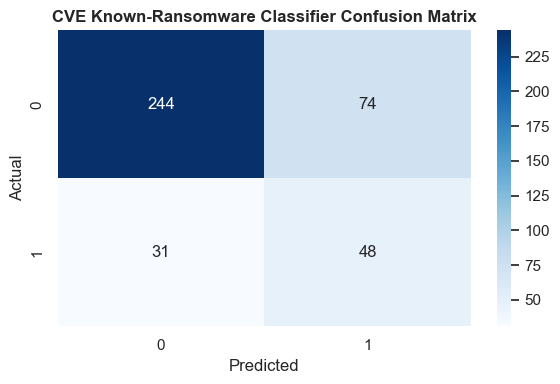

### Features Most Associated With Known Ransomware Use

,feature,coefficient
2722,cat__vendorProject_QNAP,1.428536
1934,text__server,1.410667
2739,cat__vendorProject_SonicWall,1.331218
2796,cat__product_E-Business Suite,1.218168
2830,cat__product_Java SE,1.212157
2578,cwe__CWE-404,1.120665
2878,cat__product_SharePoint,1.102921
2720,cat__vendorProject_PaperCut,1.042518
2765,cat__product_Adaptive Security Appliance (ASA) and Firepower Threat Defense (FTD),1.029550
2604,cwe__CWE-59,1.015030


### Features Least Associated With Known Ransomware Use

,feature,coefficient
2663,cat__vendorProject_Apple,-1.672170
2692,cat__vendorProject_Google,-1.460769
2857,cat__product_Office,-1.003078
2826,cat__product_Internet Explorer,-0.838874
2799,cat__product_Endpoint Manager (EPM),-0.822379
2661,cat__vendorProject_Android,-0.811902
2757,cat__vendorProject_Zoho,-0.807329
1235,text__ios,-0.794082
768,text__devices,-0.772181
179,text__allows remote,-0.760762


### CVEs With Highest Ransomware Similarity Score

,cveID,vendorProject,product,vulnerabilityName,knownRansomwareCampaignUse,cwes,ransomware_similarity_score,dueDate_dt
1438,CVE-2020-17144,Microsoft,Exchange Server,Microsoft Exchange Server Remote Code Execution Vulnerability,NaN,CWE-502,0.967559,2022-05-03
1493,CVE-2021-26857,Microsoft,Exchange Server,Microsoft Exchange Server Remote Code Execution Vulnerability,Known,CWE-502,0.956708,2022-05-03
750,CVE-2022-41082,Microsoft,Exchange Server,Microsoft Exchange Server Remote Code Execution Vulnerability,Known,CWE-502,0.953316,2022-10-21
1446,CVE-2020-0688,Microsoft,Exchange Server,Microsoft Exchange Server Validation Key Remote Code Execution Vulnerability,Known,CWE-287,0.947886,2022-05-03
1483,CVE-2021-26855,Microsoft,Exchange Server,Microsoft Exchange Server Remote Code Execution Vulnerability,Known,CWE-918,0.944322,2022-05-03
203,CVE-2025-53770,Microsoft,SharePoint,Microsoft SharePoint Deserialization of Untrusted Data Vulnerability,Known,CWE-502,0.944115,2025-07-21
1490,CVE-2019-0604,Microsoft,SharePoint,Microsoft SharePoint Remote Code Execution Vulnerability,Known,CWE-20,0.943984,2022-05-03
1442,CVE-2021-34523,Microsoft,Exchange Server,Microsoft Exchange Server Privilege Escalation Vulnerability,Known,CWE-287,0.939410,2021-11-17
202,CVE-2025-49706,Microsoft,SharePoint,Microsoft SharePoint Improper Authentication Vulnerability,Known,CWE-287,0.937348,2025-07-23
1570,CVE-2020-3992,VMware,ESXi,VMware ESXi OpenSLP Use-After-Free Vulnerability,Known,CWE-416,0.936473,2022-05-03


In [11]:
display(Markdown("### CVE Ransomware-Use Classifier"))

cve_model_df = cve[
    ["text", "vendorProject", "product", "cwes_clean", "days_to_due", "ransomware_known"]
].copy()
y = cve_model_df["ransomware_known"]
X = cve_model_df.drop(columns=["ransomware_known"])

X_train, X_test, y_train, y_test = safe_train_test_split(X, y, test_size=0.25)

cve_features = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(max_features=2500, ngram_range=(1, 2), stop_words="english", min_df=2), "text"),
        ("cwe", TfidfVectorizer(token_pattern=r"[^,\s]+", lowercase=False), "cwes_clean"),
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=2), ["vendorProject", "product"]),
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), ["days_to_due"]),
    ],
    remainder="drop",
)
cve_clf = Pipeline(
    steps=[
        ("features", cve_features),
        ("model", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]
)
cve_clf.fit(X_train, y_train)
cve_pred = cve_clf.predict(X_test)
cve_report = model_report("CVE Known-Ransomware Classifier", y_test, cve_pred, labels=[0, 1])

try:
    feature_names = cve_clf.named_steps["features"].get_feature_names_out()
    coefficients = cve_clf.named_steps["model"].coef_[0]
    coef_df = pd.DataFrame({"feature": feature_names, "coefficient": coefficients})
    display(Markdown("### Features Most Associated With Known Ransomware Use"))
    display(coef_df.sort_values("coefficient", ascending=False).head(20))
    display(Markdown("### Features Least Associated With Known Ransomware Use"))
    display(coef_df.sort_values("coefficient", ascending=True).head(20))
except Exception as exc:
    print("Feature importance extraction skipped:", exc)

cve_scored = cve.copy()
cve_scored["ransomware_similarity_score"] = cve_clf.predict_proba(X)[:, 1]
display(Markdown("### CVEs With Highest Ransomware Similarity Score"))
display(
    cve_scored.sort_values("ransomware_similarity_score", ascending=False)[
        ["cveID", "vendorProject", "product", "vulnerabilityName", "knownRansomwareCampaignUse", "cwes", "ransomware_similarity_score", "dueDate_dt"]
    ].head(25)
)

## 9. Domain Intelligence Analysis, Severity Modeling, And Anomaly Detection

In [12]:
display(Markdown("### Domain Severity And TLD Patterns"))
domain_severity = severity_ordered_counts(domains)
display(domain_severity.to_frame("count"))
fig = px.bar(domain_severity.reset_index(), x="Threat_Severity", y="count", title="Domain Threat Severity", template="plotly_white")
fig.update_layout(title_x=0.02)
fig.show()

show_top(domains["TLD"].value_counts(), "Top Domain TLDs", top_n=20)

fig = px.scatter(
    domains,
    x="Reputation_num",
    y="signal_rate",
    color="Threat_Severity",
    size="Malicious_Votes_num",
    hover_data=["Domain", "TLD", "Registrar", "Popularity_Rank_num"],
    title="Domain Reputation vs Malicious/Suspicious Vote Rate",
    template="plotly_white",
)
fig.update_layout(title_x=0.02)
fig.show()

display(Markdown("### Highest-Signal Domains"))
display(
    domains.sort_values(["Threat_Severity", "signal_rate", "Malicious_Votes_num"], ascending=[True, False, False])[
        ["Domain", "TLD", "Threat_Severity", "Reputation_num", "Malicious_Votes_num", "Suspicious_Votes_num", "signal_rate", "Popularity_Rank_num", "Last_Analysis_Date_dt"]
    ].head(25)
)

### Domain Severity And TLD Patterns

,count
Threat_Severity,
Low,145
Medium,10
High,7


### Highest-Signal Domains

,Domain,TLD,Threat_Severity,Reputation_num,Malicious_Votes_num,Suspicious_Votes_num,signal_rate,Popularity_Rank_num,Last_Analysis_Date_dt
54,update-service.net,net,High,-2,17,0,0.186813,NaN,2026-04-23 10:59:51
74,cryptoloot.pro,pro,High,0,17,0,0.186813,NaN,2026-05-01 12:08:26
76,coin-have.com,com,High,-1,17,0,0.186813,564115.0,2026-05-01 12:08:53
75,minero.cc,cc,High,0,13,2,0.164835,362931.0,2026-04-29 15:17:56
73,coinhive.com,com,High,-47,13,1,0.153846,492944.0,2026-05-01 12:43:36
117,update-java.net,net,High,0,13,0,0.142857,NaN,2026-04-13 09:07:47
78,monero-miner.net,net,High,0,11,1,0.131868,749664.0,2026-04-26 23:46:24
142,exploit-db.com,com,Low,1,3,1,0.043956,13825.0,2026-05-01 06:27:23
149,carder.pro,pro,Low,0,3,1,0.043956,454147.0,2026-03-14 15:12:32
100,rarbg.to,to,Low,0,2,1,0.032967,2018.0,2026-04-30 20:04:50


### Domain Threat Severity Classifier

### Domain Severity Classifier

,model,accuracy,balanced_accuracy
0,Domain Severity Classifier,1.0,1.0


              precision    recall  f1-score   support

        High       1.00      1.00      1.00         2
         Low       1.00      1.00      1.00        44
      Medium       1.00      1.00      1.00         3

    accuracy                           1.00        49
   macro avg       1.00      1.00      1.00        49
weighted avg       1.00      1.00      1.00        49



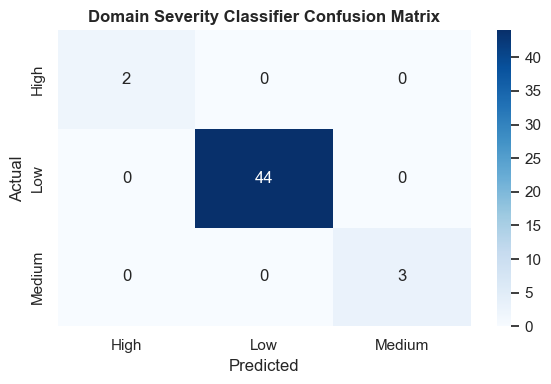

,feature,importance
11,num__malicious_rate,0.199739
13,num__signal_rate,0.196368
4,num__Malicious_Votes_num,0.191678
6,num__Harmless_Votes_num,0.094134
10,num__domain_age_days,0.050093
9,num__Popularity_Rank_num,0.048661
7,num__Undetected_Votes_num,0.047496
0,num__Domain_Length_num,0.034483
12,num__suspicious_rate,0.021631
5,num__Suspicious_Votes_num,0.019426


### Most Anomalous Domains

,Domain,TLD,Threat_Severity,Reputation_num,Malicious_Votes_num,signal_rate,anomaly_score,Registrar
75,minero.cc,cc,High,0,13,0.164835,-0.107564,Key-Systems GmbH
108,superfish.com,com,Medium,0,9,0.120879,-0.091136,NaN
73,coinhive.com,com,High,-47,13,0.153846,-0.088793,1API GmbH
54,update-service.net,net,High,-2,17,0.186813,-0.073451,NaN
37,whatsapp-verify.net,net,Low,0,0,0.032967,-0.070708,NaN
74,cryptoloot.pro,pro,High,0,17,0.186813,-0.068378,NaN
76,coin-have.com,com,High,-1,17,0.186813,-0.067908,NaN
78,monero-miner.net,net,High,0,11,0.131868,-0.025896,"Gransy, s.r.o."
98,1337x.to,to,Low,3,1,0.021978,-0.021506,Government of Kingdom of Tonga
117,update-java.net,net,High,0,13,0.142857,-0.012564,"GMO INTERNET, INC. DBA ONAMAE.COM"


In [13]:
display(Markdown("### Domain Threat Severity Classifier"))

domain_feature_cols_num = [
    "Domain_Length_num", "Has_Numbers_bin", "Has_Hyphen_bin", "Reputation_num",
    "Malicious_Votes_num", "Suspicious_Votes_num", "Harmless_Votes_num",
    "Undetected_Votes_num", "Total_Engines_num", "Popularity_Rank_num",
    "domain_age_days", "malicious_rate", "suspicious_rate", "signal_rate"
]
domain_feature_cols_cat = ["TLD", "Registrar", "Data_Source"]

domain_model_df = domains.dropna(subset=["Threat_Severity"]).copy()
X = domain_model_df[domain_feature_cols_num + domain_feature_cols_cat]
y = domain_model_df["Threat_Severity"]
X_train, X_test, y_train, y_test = safe_train_test_split(X, y, test_size=0.30)

domain_preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), domain_feature_cols_num),
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=2), domain_feature_cols_cat),
    ]
)
domain_clf = Pipeline(
    steps=[
        ("features", domain_preprocess),
        ("model", RandomForestClassifier(
            n_estimators=400,
            random_state=RANDOM_STATE,
            class_weight="balanced_subsample",
            min_samples_leaf=2,
        )),
    ]
)
domain_clf.fit(X_train, y_train)
domain_pred = domain_clf.predict(X_test)
domain_labels = sorted(y.unique())
domain_report = model_report("Domain Severity Classifier", y_test, domain_pred, labels=domain_labels)

# Feature importance for transformed feature space.
try:
    domain_feature_names = domain_clf.named_steps["features"].get_feature_names_out()
    domain_importances = domain_clf.named_steps["model"].feature_importances_
    domain_importance_df = pd.DataFrame(
        {"feature": domain_feature_names, "importance": domain_importances}
    ).sort_values("importance", ascending=False)
    display(domain_importance_df.head(25))
    fig = px.bar(
        domain_importance_df.head(20).sort_values("importance"),
        x="importance",
        y="feature",
        orientation="h",
        title="Domain Severity Model: Top Feature Importances",
        template="plotly_white",
    )
    fig.update_layout(title_x=0.02, height=620)
    fig.show()
except Exception as exc:
    print("Domain feature importance extraction skipped:", exc)

domain_anomalies = numeric_anomaly_detection(
    domains,
    feature_cols=domain_feature_cols_num,
    id_col="Domain",
    contamination=0.08,
)
domains_scored = domains.merge(
    domain_anomalies[["Domain", "anomaly_flag", "anomaly_score"]],
    on="Domain",
    how="left",
)
display(Markdown("### Most Anomalous Domains"))
display(
    domains_scored.sort_values("anomaly_score")[
        ["Domain", "TLD", "Threat_Severity", "Reputation_num", "Malicious_Votes_num", "signal_rate", "anomaly_score", "Registrar"]
    ].head(20)
)

fig = px.scatter(
    domains_scored,
    x="signal_rate",
    y="anomaly_score",
    color="Threat_Severity",
    hover_data=["Domain", "TLD", "Registrar"],
    title="Domain Anomaly Score vs Vote Signal Rate",
    template="plotly_white",
)
fig.update_layout(title_x=0.02)
fig.show()

## 10. IP Intelligence Analysis, Severity Modeling, And Anomaly Detection

In [14]:
display(Markdown("### IP Severity, Geography, Registry, And TOR Patterns"))
ip_severity = severity_ordered_counts(ips)
display(ip_severity.to_frame("count"))
fig = px.bar(ip_severity.reset_index(), x="Threat_Severity", y="count", title="IP Threat Severity", template="plotly_white")
fig.update_layout(title_x=0.02)
fig.show()

show_top(ips["Country"].fillna("Missing").value_counts(), "Top IP Countries", top_n=20)
show_top(ips["Owner"].fillna("Missing").value_counts(), "Top IP Owners", top_n=20)
show_top(ips["Regional_Registry"].fillna("Missing").value_counts(), "Top Regional Registries", top_n=10)

tor_counts = ips["TOR_Node"].fillna("Missing").value_counts()
display(tor_counts.to_frame("count"))

fig = px.scatter(
    ips,
    x="Reputation_Score_num",
    y="signal_rate",
    color="Threat_Severity",
    size="Malicious_Votes_num",
    hover_data=["IP", "Country", "ASN_num", "Owner", "TOR_Node"],
    title="IP Reputation vs Malicious/Suspicious Vote Rate",
    template="plotly_white",
)
fig.update_layout(title_x=0.02)
fig.show()

### IP Severity, Geography, Registry, And TOR Patterns

,count
Threat_Severity,
Low,174
Medium,14
High,12


,count
TOR_Node,
No,189
Yes,11


### IP Threat Severity Classifier

### IP Severity Classifier

,model,accuracy,balanced_accuracy
0,IP Severity Classifier,1.0,1.0


              precision    recall  f1-score   support

        High       1.00      1.00      1.00         4
         Low       1.00      1.00      1.00        52
      Medium       1.00      1.00      1.00         4

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



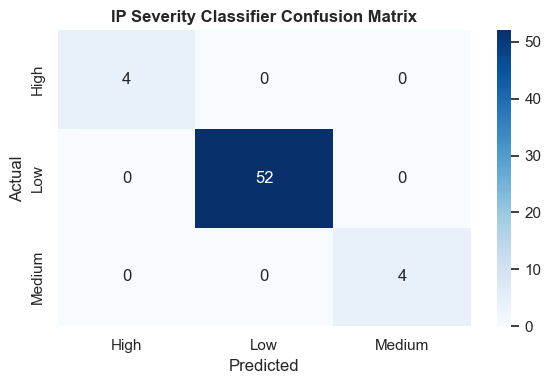

,feature,importance
9,num__malicious_rate,0.153496
1,num__Malicious_Votes_num,0.151705
11,num__signal_rate,0.142354
4,num__Undetected_Votes_num,0.076862
6,num__Reputation_Score_num,0.065139
3,num__Harmless_Votes_num,0.060297
60,cat__Owner_Stiftung Erneuerbare Freiheit,0.045087
0,num__ASN_num,0.039555
8,num__TOR_Node_bin,0.039457
76,cat__Threat_Category_unrated,0.039307


### Most Anomalous IPs

,IP,Country,Owner,Threat_Severity,Reputation_Score_num,Malicious_Votes_num,signal_rate,TOR_Node,anomaly_score
144,89.248.167.131,NL,IP Volume inc,High,-85,21,0.230769,No,-0.184408
14,185.220.101.13,DE,Stiftung Erneuerbare Freiheit,High,-28,18,0.230769,Yes,-0.102065
7,185.220.101.2,DE,Stiftung Erneuerbare Freiheit,High,-14,11,0.164835,Yes,-0.063223
6,185.220.101.1,DE,Stiftung Erneuerbare Freiheit,High,-23,17,0.208791,Yes,-0.056851
48,158.247.210.58,KR,"The Constant Company, LLC",Medium,0,9,0.131868,No,-0.056606
15,185.220.101.14,DE,Stiftung Erneuerbare Freiheit,High,-26,12,0.175824,Yes,-0.053436
10,185.220.101.9,DE,Stiftung Erneuerbare Freiheit,High,-57,13,0.175824,Yes,-0.034404
3,77.247.181.163,NL,NForce Entertainment B.V.,Low,-16,2,0.043956,No,-0.024738
41,5.188.206.15,BG,Krez 999 Eood,Low,0,1,0.010989,No,-0.023620
43,5.188.206.17,BG,Krez 999 Eood,Low,0,1,0.010989,No,-0.023620


In [15]:
display(Markdown("### IP Threat Severity Classifier"))

ip_feature_cols_num = [
    "ASN_num", "Malicious_Votes_num", "Suspicious_Votes_num", "Harmless_Votes_num",
    "Undetected_Votes_num", "Total_Reports_num", "Reputation_Score_num",
    "Times_Submitted_num", "TOR_Node_bin", "malicious_rate", "suspicious_rate", "signal_rate"
]
ip_feature_cols_cat = ["Country", "Continent", "Owner", "Regional_Registry", "Threat_Label", "Threat_Category"]

ip_model_df = ips.dropna(subset=["Threat_Severity"]).copy()
X = ip_model_df[ip_feature_cols_num + ip_feature_cols_cat]
y = ip_model_df["Threat_Severity"]
X_train, X_test, y_train, y_test = safe_train_test_split(X, y, test_size=0.30)

ip_preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), ip_feature_cols_num),
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=2), ip_feature_cols_cat),
    ]
)
ip_clf = Pipeline(
    steps=[
        ("features", ip_preprocess),
        ("model", RandomForestClassifier(
            n_estimators=400,
            random_state=RANDOM_STATE,
            class_weight="balanced_subsample",
            min_samples_leaf=2,
        )),
    ]
)
ip_clf.fit(X_train, y_train)
ip_pred = ip_clf.predict(X_test)
ip_labels = sorted(y.unique())
ip_report = model_report("IP Severity Classifier", y_test, ip_pred, labels=ip_labels)

try:
    ip_feature_names = ip_clf.named_steps["features"].get_feature_names_out()
    ip_importances = ip_clf.named_steps["model"].feature_importances_
    ip_importance_df = pd.DataFrame(
        {"feature": ip_feature_names, "importance": ip_importances}
    ).sort_values("importance", ascending=False)
    display(ip_importance_df.head(25))
    fig = px.bar(
        ip_importance_df.head(20).sort_values("importance"),
        x="importance",
        y="feature",
        orientation="h",
        title="IP Severity Model: Top Feature Importances",
        template="plotly_white",
    )
    fig.update_layout(title_x=0.02, height=620)
    fig.show()
except Exception as exc:
    print("IP feature importance extraction skipped:", exc)

ip_anomalies = numeric_anomaly_detection(
    ips,
    feature_cols=ip_feature_cols_num,
    id_col="IP",
    contamination=0.08,
)
ips_scored = ips.merge(
    ip_anomalies[["IP", "anomaly_flag", "anomaly_score"]],
    on="IP",
    how="left",
)
display(Markdown("### Most Anomalous IPs"))
display(
    ips_scored.sort_values("anomaly_score")[
        ["IP", "Country", "Owner", "Threat_Severity", "Reputation_Score_num", "Malicious_Votes_num", "signal_rate", "TOR_Node", "anomaly_score"]
    ].head(20)
)

fig = px.scatter(
    ips_scored,
    x="signal_rate",
    y="anomaly_score",
    color="Threat_Severity",
    symbol="TOR_Node",
    hover_data=["IP", "Country", "Owner", "ASN_num"],
    title="IP Anomaly Score vs Vote Signal Rate",
    template="plotly_white",
)
fig.update_layout(title_x=0.02)
fig.show()

## 11. Cross-Dataset Synthesis

There is no reliable shared key across these four datasets. This section therefore avoids fake joins and instead creates an analyst synthesis from comparable signals: ransomware themes, MITRE techniques, CVE exposure, high-severity domains, and high-severity IPs.

In [16]:
ransomware_otx = otx[
    otx[["Title", "Description", "Tags", "Malware_Families"]]
    .fillna("")
    .agg(" ".join, axis=1)
    .str.contains("ransomware", case=False, na=False)
].copy()

phishing_otx = otx[
    otx[["Title", "Description", "Tags"]]
    .fillna("")
    .agg(" ".join, axis=1)
    .str.contains("phishing|credential|stealer|infostealer", case=False, regex=True, na=False)
].copy()

known_ransomware_cves = cve_scored[cve_scored["knownRansomwareCampaignUse"].eq("Known")].copy()

high_domain = domains_scored[domains_scored["Threat_Severity"].isin(["High", "Critical"])].copy()
high_ip = ips_scored[ips_scored["Threat_Severity"].isin(["High", "Critical"])].copy()

synthesis = pd.DataFrame(
    [
        {"signal": "OTX ransomware-themed pulses", "count": len(ransomware_otx)},
        {"signal": "OTX phishing / credential theft / stealer-themed pulses", "count": len(phishing_otx)},
        {"signal": "CVEs labeled known ransomware campaign use", "count": len(known_ransomware_cves)},
        {"signal": "High/Critical malicious domains", "count": len(high_domain)},
        {"signal": "High/Critical malicious IPs", "count": len(high_ip)},
    ]
)
display(synthesis)

display(Markdown("### Priority CVEs"))
display(
    cve_scored.sort_values(["ransomware_known", "ransomware_similarity_score", "dateAdded_dt"], ascending=[False, False, False])[
        ["cveID", "vendorProject", "product", "vulnerabilityName", "knownRansomwareCampaignUse", "ransomware_similarity_score", "dateAdded_dt", "dueDate_dt", "cwes"]
    ].head(30)
)

display(Markdown("### Priority Domains"))
display(
    domains_scored.sort_values(["Threat_Severity", "signal_rate", "anomaly_score"], ascending=[True, False, True])[
        ["Domain", "TLD", "Threat_Severity", "Reputation_num", "Malicious_Votes_num", "Suspicious_Votes_num", "signal_rate", "anomaly_score", "Registrar"]
    ].head(30)
)

display(Markdown("### Priority IPs"))
display(
    ips_scored.sort_values(["Threat_Severity", "signal_rate", "anomaly_score"], ascending=[True, False, True])[
        ["IP", "Country", "ASN_num", "Owner", "Threat_Severity", "Reputation_Score_num", "Malicious_Votes_num", "signal_rate", "TOR_Node", "anomaly_score"]
    ].head(30)
)

,signal,count
0,OTX ransomware-themed pulses,289
1,OTX phishing / credential theft / stealer-themed pulses,1111
2,CVEs labeled known ransomware campaign use,317
3,High/Critical malicious domains,7
4,High/Critical malicious IPs,12


### Priority CVEs

,cveID,vendorProject,product,vulnerabilityName,knownRansomwareCampaignUse,ransomware_similarity_score,dateAdded_dt,dueDate_dt,cwes
1493,CVE-2021-26857,Microsoft,Exchange Server,Microsoft Exchange Server Remote Code Execution Vulnerability,Known,0.956708,2021-11-03,2022-05-03,CWE-502
750,CVE-2022-41082,Microsoft,Exchange Server,Microsoft Exchange Server Remote Code Execution Vulnerability,Known,0.953316,2022-09-30,2022-10-21,CWE-502
1446,CVE-2020-0688,Microsoft,Exchange Server,Microsoft Exchange Server Validation Key Remote Code Execution Vulnerability,Known,0.947886,2021-11-03,2022-05-03,CWE-287
1483,CVE-2021-26855,Microsoft,Exchange Server,Microsoft Exchange Server Remote Code Execution Vulnerability,Known,0.944322,2021-11-03,2022-05-03,CWE-918
203,CVE-2025-53770,Microsoft,SharePoint,Microsoft SharePoint Deserialization of Untrusted Data Vulnerability,Known,0.944115,2025-07-20,2025-07-21,CWE-502
1490,CVE-2019-0604,Microsoft,SharePoint,Microsoft SharePoint Remote Code Execution Vulnerability,Known,0.943984,2021-11-03,2022-05-03,CWE-20
1442,CVE-2021-34523,Microsoft,Exchange Server,Microsoft Exchange Server Privilege Escalation Vulnerability,Known,0.939410,2021-11-03,2021-11-17,CWE-287
202,CVE-2025-49706,Microsoft,SharePoint,Microsoft SharePoint Improper Authentication Vulnerability,Known,0.937348,2025-07-22,2025-07-23,CWE-287
1570,CVE-2020-3992,VMware,ESXi,VMware ESXi OpenSLP Use-After-Free Vulnerability,Known,0.936473,2021-11-03,2022-05-03,CWE-416
445,CVE-2024-37085,VMware,ESXi,VMware ESXi Authentication Bypass Vulnerability,Known,0.936442,2024-07-30,2024-08-20,CWE-305


### Priority Domains

,Domain,TLD,Threat_Severity,Reputation_num,Malicious_Votes_num,Suspicious_Votes_num,signal_rate,anomaly_score,Registrar
54,update-service.net,net,High,-2,17,0,0.186813,-0.073451,NaN
74,cryptoloot.pro,pro,High,0,17,0,0.186813,-0.068378,NaN
76,coin-have.com,com,High,-1,17,0,0.186813,-0.067908,NaN
75,minero.cc,cc,High,0,13,2,0.164835,-0.107564,Key-Systems GmbH
73,coinhive.com,com,High,-47,13,1,0.153846,-0.088793,1API GmbH
117,update-java.net,net,High,0,13,0,0.142857,-0.012564,"GMO INTERNET, INC. DBA ONAMAE.COM"
78,monero-miner.net,net,High,0,11,1,0.131868,-0.025896,"Gransy, s.r.o."
142,exploit-db.com,com,Low,1,3,1,0.043956,0.037953,GANDI SAS
149,carder.pro,pro,Low,0,3,1,0.043956,0.088233,One.com A/S
37,whatsapp-verify.net,net,Low,0,0,3,0.032967,-0.070708,NaN


### Priority IPs

,IP,Country,ASN_num,Owner,Threat_Severity,Reputation_Score_num,Malicious_Votes_num,signal_rate,TOR_Node,anomaly_score
144,89.248.167.131,NL,202425.0,IP Volume inc,High,-85,21,0.230769,No,-0.184408
14,185.220.101.13,DE,60729.0,Stiftung Erneuerbare Freiheit,High,-28,18,0.230769,Yes,-0.102065
6,185.220.101.1,DE,60729.0,Stiftung Erneuerbare Freiheit,High,-23,17,0.208791,Yes,-0.056851
15,185.220.101.14,DE,60729.0,Stiftung Erneuerbare Freiheit,High,-26,12,0.175824,Yes,-0.053436
10,185.220.101.9,DE,60729.0,Stiftung Erneuerbare Freiheit,High,-57,13,0.175824,Yes,-0.034404
8,185.220.101.3,DE,60729.0,Stiftung Erneuerbare Freiheit,High,-16,14,0.175824,Yes,-0.003510
11,185.220.101.10,DE,60729.0,Stiftung Erneuerbare Freiheit,High,-14,14,0.175824,Yes,-0.002327
13,185.220.101.12,DE,60729.0,Stiftung Erneuerbare Freiheit,High,-16,13,0.175824,Yes,0.024627
7,185.220.101.2,DE,60729.0,Stiftung Erneuerbare Freiheit,High,-14,11,0.164835,Yes,-0.063223
9,185.220.101.4,DE,60729.0,Stiftung Erneuerbare Freiheit,High,-18,12,0.164835,Yes,0.009722


## 12. Final Findings Generator

This cell produces a concise, data-driven research summary from the computed outputs.

In [17]:
newest_otx = otx["Created_dt"].max()
newest_cve = cve["dateAdded_dt"].max()
newest_domain = domains["Last_Analysis_Date_dt"].max()
newest_ip = ips["Last_Analysis_Date_dt"].max()

top_attack = top_attack_ids.index[0] if len(top_attack_ids) else "n/a"
top_tag = top_tags.index[0] if len(top_tags) else "n/a"
top_cwe = top_cwes.index[0] if len(top_cwes) else "n/a"

final_markdown = f'''
## Executive Research Summary

**Coverage.** The notebook analyzed {len(otx):,} de-duplicated OTX pulses, {len(cve):,} CVEs, {len(domains):,} domains, and {len(ips):,} IPs.

**Freshness.** Latest observed dates: OTX `{newest_otx}`, CVE additions `{newest_cve}`, domain analysis `{newest_domain}`, and IP analysis `{newest_ip}`.

**Threat themes.** The strongest OTX tag signal is **{top_tag}**, and the most frequent MITRE ATT&CK technique ID is **{top_attack}**.

**Vulnerability exposure.** The leading CWE signal is **{top_cwe}**. CVE ransomware modeling should be read as similarity-based triage because `Unknown` is not a verified negative class.

**Infrastructure risk.** Domain/IP severity and anomaly models identify high-signal outliers using scanner votes, reputation, geography/registry ownership, and structural features.

**Analyst action.** Prioritize the generated CVE/domain/IP tables for validation, enrichment, and defensive control mapping. Do not directly operationalize model predictions without human review and current external threat-intel confirmation.
'''
display(Markdown(final_markdown))

model_scorecard = pd.DataFrame([cve_report, domain_report, ip_report])
display(Markdown("### Model Scorecard"))
display(model_scorecard)


## Executive Research Summary

**Coverage.** The notebook analyzed 2,340 de-duplicated OTX pulses, 1,585 CVEs, 162 domains, and 200 IPs.

**Freshness.** Latest observed dates: OTX `2026-04-29 10:49:26.327000`, CVE additions `2026-04-28 00:00:00`, domain analysis `2026-05-01 12:50:20`, and IP analysis `2026-05-01 10:44:10`.

**Threat themes.** The strongest OTX tag signal is **phishing**, and the most frequent MITRE ATT&CK technique ID is **T1027**.

**Vulnerability exposure.** The leading CWE signal is **CWE-20**. CVE ransomware modeling should be read as similarity-based triage because `Unknown` is not a verified negative class.

**Infrastructure risk.** Domain/IP severity and anomaly models identify high-signal outliers using scanner votes, reputation, geography/registry ownership, and structural features.

**Analyst action.** Prioritize the generated CVE/domain/IP tables for validation, enrichment, and defensive control mapping. Do not directly operationalize model predictions without human review and current external threat-intel confirmation.


### Model Scorecard

,model,accuracy,balanced_accuracy
0,CVE Known-Ransomware Classifier,0.735516,0.687445
1,Domain Severity Classifier,1.000000,1.000000
2,IP Severity Classifier,1.000000,1.000000


## 13. Reproducibility Checklist

- Source paths are centralized in `DATA_PATHS`.
- Expected parsed row counts are encoded in `EXPECTED_ROWS`.
- Randomized ML steps use `RANDOM_STATE = 42`.
- Original CSV files are read only and are not modified.
- Cross-dataset conclusions are synthesized without unsupported joins.